##  Existe t-il des profils de consommateurs homogènes ?

## ⚙️ACP et K-means

### ➡️ Import des librairies et Dataset  

In [7]:
import pandas as pd
import numpy as np
np.long = np.int_
np.int = int
np.float = float
np.bool = bool
np.ulong = np.uint64
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [9]:
data = pd.read_csv("Data/marketing_campaign_S3.csv", sep = "\t")
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [10]:
data.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

### ➡️ Nettoyage et préparation

In [11]:
# Suppression des lignes avec valeurs manquantes
data = data.dropna()

# Création de l'âge
data["Age"] = 2024 - data["Year_Birth"]

# Dépense totale
data["Total_Spending"] = data[[
    "MntWines","MntFruits","MntMeatProducts","MntFishProducts",
    "MntSweetProducts","MntGoldProds"
]].sum(axis=1)

# Engagement marketing
data["Marketing_Engagement"] = data[[
    "Response","Complain","NumDealsPurchases","NumWebVisitsMonth"
]].sum(axis=1)

# Variables pour le clustering
features = ["Age","Income","Total_Spending","Marketing_Engagement",
            "Kidhome","Teenhome","Recency"]

X = data[features]


### ➡️ Normalisation et ACP

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Variance expliquée :", pca.explained_variance_ratio_)

Variance expliquée : [0.35484499 0.20416345]


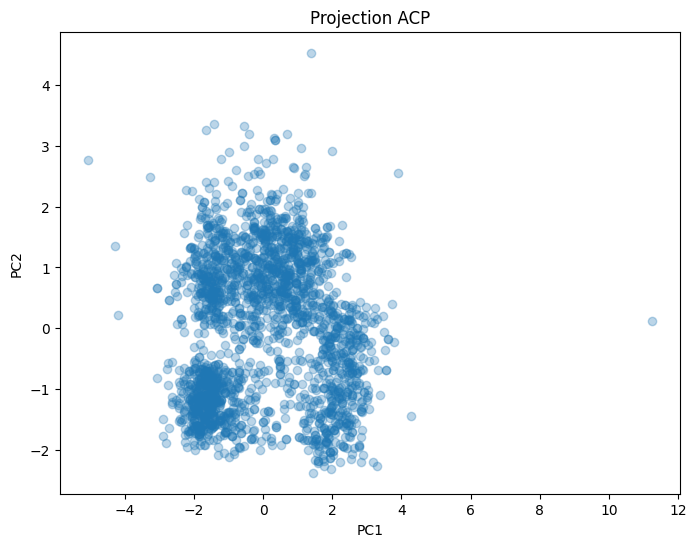

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.3)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Projection ACP")
plt.show()


### ➡️ Recherche du nombre optimal de clusters

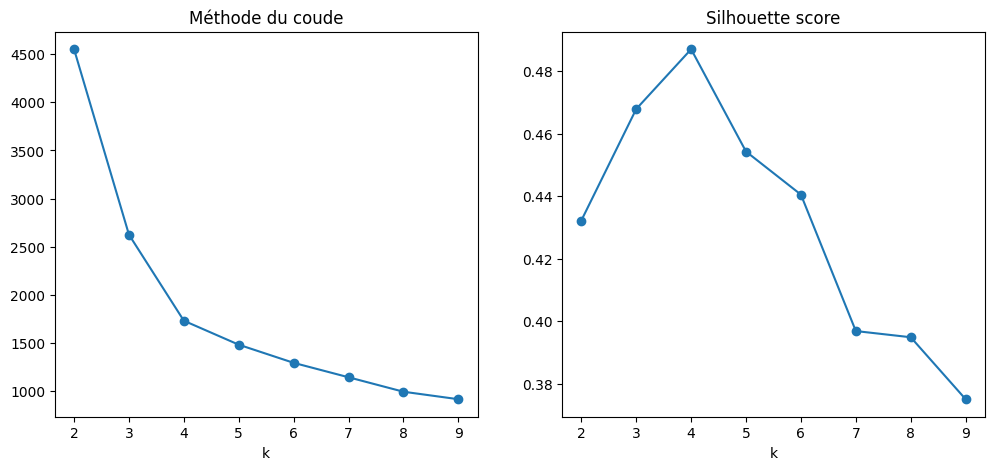

In [15]:
inertia = []
silhouette = []
K = range(2,10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_pca)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_pca, km.labels_))

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(K, inertia, marker="o")
plt.title("Méthode du coude")
plt.xlabel("k")

plt.subplot(1,2,2)
plt.plot(K, silhouette, marker="o")
plt.title("Silhouette score")
plt.xlabel("k")

plt.show()

### ➡️ Clustering final

In [ ]:
k_optimal = 4  # je me suis basé sur les courbes
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
data["Cluster"] = kmeans.fit_predict(X_pca)

### ➡️ Visualisation des clusters

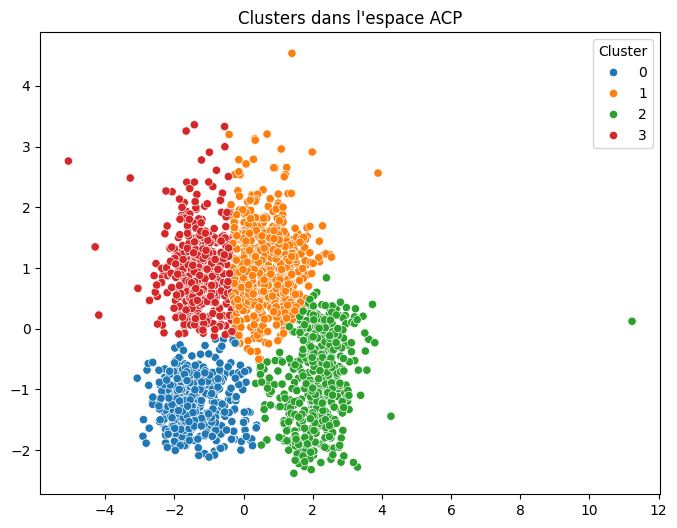

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=data["Cluster"], palette="tab10")
plt.title("Clusters dans l'espace ACP")
plt.show()


### ➡️ Profiling des segments

In [20]:
cluster_profile = data.groupby("Cluster")[features].mean()
cluster_profile

,Age,Income,Total_Spending,Marketing_Engagement,Kidhome,Teenhome,Recency
Cluster,,,,,,,
0,45.114140,31550.477002,151.928450,8.981261,0.882453,0.003407,48.335605
1,61.989346,58628.184170,723.677321,7.884323,0.033486,0.945205,49.558600
2,54.740000,78918.086000,1388.236000,3.870000,0.032000,0.042000,50.022000
3,58.684322,40851.735169,183.311441,10.387712,0.896186,1.008475,48.025424


### ➡️ Résumé

L’analyse combinée ACP + KMeans montre que les consommateurs ne forment pas un ensemble homogène.
Au contraire, ils se répartissent en plusieurs segments distincts, révélés par :
la projection ACP (où les individus se regroupent naturellement), la méthode du coude (qui suggère un nombre optimal de clusters), le score de silhouette (qui confirme la cohérence des groupes) et la visualisation des clusters dans l’espace des composantes principales.

Cela signifie que les comportements, les dépenses, les préférences ou les caractéristiques socio‑démographiques des clients présentent des patterns récurrents, suffisamment marqués pour être segmentés.

Les méthodes du coude et du score de silhouette convergent vers k = 4 clusters, ce qui indique une segmentation en quatre groupes cohérents et bien séparés.
L’analyse des caractéristiques moyennes de chaque cluster révèle des profils distincts :
– Cluster 0 : ménages modestes, peu dépensiers, sensibles aux promotions mais avec un pouvoir d’achat limité.
– Cluster 1 : consommateurs matures, dépensiers, avec des besoins spécifiques liés à des adolescents. Segment intéressant pour des campagnes ciblées.
– Cluster 2 : clients premium, très rentables, mais peu réactifs aux campagnes marketing.
Segment à privilégier via des offres exclusives plutôt que des promotions classiques
– Cluster 3 : ménages engagés dans les campagnes, mais avec un budget limité.
Segment idéal pour les promotions, coupons, programmes de fidélité.

Conclusion : Au vu de ces résultats, l’entreprise ou la structure peut ainsi optimiser ses actions commerciales, améliorer la pertinence de ses  prochaines campagnes et augmenter son retour sur investissement. Cette approche analytique fournit une base solide pour une stratégie marketing plus personnalisée, plus efficiente et mieux alignée sur les attentes réelles des consommateurs.